# Dataset Generation for Multi-Output Seq2Seq Battery Formation Surrogates

This notebook generates **18 new formation datasets** using PyBaMM:

- 6 multi-stage formation protocols
- 6 slow single-cycle formation protocols
- 6 fast single-cycle formation protocols

The datasets are saved to `../data/raw/` by default.

Each CSV includes:
- Time
- Current
- Terminal voltage
- Cell temperature
- Negative SEI thickness
- SEI growth rate
- Total lithium capacity
- Cumulative charge features
- Regime and protocol labels


In [ ]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

print("PyBaMM version:", pybamm.__version__)


PyBaMM version: 26.4.1


## 1. Output directory

In [ ]:
candidate_path = Path("../data/raw")
if not candidate_path.parent.exists():
    candidate_path = Path("data/raw")

RAW_DIR = candidate_path
RAW_DIR.mkdir(parents=True, exist_ok=True)

print("Datasets will be saved to:", RAW_DIR.resolve())


Datasets will be saved to: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/data/raw


## 2. DFN model and parameter setup

In [3]:
model = pybamm.lithium_ion.DFN(
    options={
        "open-circuit potential": "single",
        "intercalation kinetics": "symmetric Butler-Volmer",
        "thermal": "lumped",
        "surface form": "algebraic",
        "surface temperature": "lumped",
        "SEI": "ec reaction limited",
        "SEI film resistance": "distributed",
        "SEI porosity change": "true",
        "calculate discharge energy": "false",
        "cell geometry": "arbitrary",
        "calculate heat source for isothermal models": "false",
        "current collector": "uniform",
        "diffusivity": "single",
        "exchange-current density": "single",
        "lithium plating": "irreversible",
        "lithium plating porosity change": "true",
    }
)

parameter_values = pybamm.ParameterValues("Mohtat2020")

# Extra thermal parameters required by this model configuration.
parameter_values.update(
    {
        "Casing heat capacity [J.K-1]": 300.0,
        "Environment thermal resistance [K.W-1]": 2.0,
    },
    check_already_exists=False,
)

solver = pybamm.IDAKLUSolver(
    rtol=1e-4,
    atol=1e-6,
    options={"max_num_steps": 50000},
)

print("Model, parameters, and solver are ready.")


Model, parameters, and solver are ready.


## 3. Formation protocols

The initial rest period provides a consistent initial condition before current is applied.


In [4]:
# -----------------------------
# Multi-stage formation protocols
# -----------------------------

experiment_multi_1 = pybamm.Experiment([
    (
        "Rest for 45 minutes",
        "Charge at 0.03C until 2.2V",
        "Rest for 360 minutes",
        "Charge at 0.06C until 3.5V",
        "Hold at 3.5V until C/45",
        "Rest for 240 minutes",
    ),
    (
        "Charge at 0.12C until 4.1V",
        "Hold at 4.1V until C/25",
        "Discharge at 0.08C until 2.9V",
    ) * 2,
    (
        "Rest for 2 hours",
    ),
])

experiment_multi_2 = pybamm.Experiment([
    (
        "Rest for 1 hour",
        "Charge at 0.04C until 2.8V",
        "Rest for 480 minutes",
        "Charge at 0.08C until 3.7V",
        "Hold at 3.7V until C/40",
        "Rest for 360 minutes",
    ),
    (
        "Charge at 0.15C until 4.05V",
        "Hold at 4.05V until C/25",
        "Discharge at 0.1C until 3.0V",
    ) * 2,
    (
        "Charge at 0.08C until 4.1V",
        "Hold at 4.1V until C/30",
        "Rest for 3 hours",
    ),
])

experiment_multi_3 = pybamm.Experiment([
    (
        "Rest for 30 minutes",
        "Charge at 0.025C until 2.5V",
        "Rest for 300 minutes",
        "Charge at 0.075C until 3.6V",
        "Rest for 180 minutes",
    ),
    (
        "Charge at 0.1C until 4.0V",
        "Hold at 4.0V until C/30",
        "Discharge at 0.08C until 2.8V",
    ) * 3,
    (
        "Rest for 2 hours",
    ),
])

experiment_multi_4 = pybamm.Experiment([
    (
        "Rest for 90 minutes",
        "Charge at 0.05C until 3.0V",
        "Hold at 3.0V until C/50",
        "Rest for 360 minutes",
        "Charge at 0.1C until 3.8V",
        "Hold at 3.8V until C/35",
        "Rest for 240 minutes",
    ),
    (
        "Charge at 0.15C until 4.1V",
        "Hold at 4.1V until C/20",
        "Discharge at 0.1C until 2.8V",
    ) * 2,
])

experiment_multi_5 = pybamm.Experiment([
    (
        "Rest for 1 hour",
        "Charge at 0.035C until 2.6V",
        "Rest for 240 minutes",
        "Charge at 0.07C until 3.7V",
        "Hold at 3.7V until C/45",
        "Rest for 240 minutes",
    ),
    (
        "Charge at 0.12C until 4.1V",
        "Hold at 4.1V until C/30",
        "Discharge at 0.1C until 2.7V",
    ) * 2,
    (
        "Charge at 0.05C until 4.1V",
        "Hold at 4.1V until C/40",
        "Rest for 2 hours",
    ),
])

experiment_multi_6 = pybamm.Experiment([
    (
        "Rest for 45 minutes",
        "Charge at 0.045C until 2.4V",
        "Rest for 300 minutes",
        "Charge at 0.09C until 3.6V",
        "Hold at 3.6V until C/40",
        "Rest for 180 minutes",
    ),
    (
        "Charge at 0.18C until 4.05V",
        "Hold at 4.05V until C/25",
        "Discharge at 0.12C until 2.8V",
    ) * 2,
    (
        "Rest for 3 hours",
    ),
])


In [5]:
# -----------------------------
# Slow single-cycle formation protocols
# -----------------------------

experiment_slow_1 = pybamm.Experiment([
    (
        "Rest for 1 hour",
        "Charge at 0.04C until 4.05V",
        "Hold at 4.05V until C/40",
        "Discharge at 0.04C until 2.8V",
        "Rest for 1 hour",
    ),
])

experiment_slow_2 = pybamm.Experiment([
    (
        "Rest for 90 minutes",
        "Charge at 0.06C until 3.9V",
        "Hold at 3.9V until C/45",
        "Charge at 0.04C until 4.1V",
        "Hold at 4.1V until C/35",
        "Discharge at 0.05C until 2.8V",
    ),
])

experiment_slow_3 = pybamm.Experiment([
    (
        "Rest for 45 minutes",
        "Charge at 0.075C until 4.0V",
        "Hold at 4.0V until C/35",
        "Discharge at 0.05C until 2.9V",
        "Rest for 90 minutes",
    ),
])

experiment_slow_4 = pybamm.Experiment([
    (
        "Rest for 2 hours",
        "Charge at 0.05C until 3.7V",
        "Hold at 3.7V until C/50",
        "Charge at 0.05C until 4.1V",
        "Hold at 4.1V until C/40",
        "Discharge at 0.04C until 2.7V",
    ),
])

experiment_slow_5 = pybamm.Experiment([
    (
        "Rest for 1 hour",
        "Charge at 0.08C until 4.05V",
        "Hold at 4.05V until C/30",
        "Discharge at 0.06C until 2.8V",
        "Rest for 2 hours",
    ),
])

experiment_slow_6 = pybamm.Experiment([
    (
        "Rest for 75 minutes",
        "Charge at 0.055C until 3.95V",
        "Hold at 3.95V until C/45",
        "Charge at 0.04C until 4.1V",
        "Hold at 4.1V until C/40",
        "Discharge at 0.05C until 2.75V",
        "Rest for 1 hour",
    ),
])


In [6]:
# -----------------------------
# Fast single-cycle formation protocols
# -----------------------------

experiment_fast_1 = pybamm.Experiment([
    (
        "Rest for 15 minutes",
        "Charge at 0.55C until 4.05V",
        "Hold at 4.05V until C/9",
        "Discharge at 0.35C until 2.8V",
        "Rest for 15 minutes",
    ),
])

experiment_fast_2 = pybamm.Experiment([
    (
        "Rest for 20 minutes",
        "Charge at 0.65C until 4.1V",
        "Hold at 4.1V until C/8",
        "Discharge at 0.45C until 2.8V",
    ),
])

experiment_fast_3 = pybamm.Experiment([
    (
        "Rest for 10 minutes",
        "Charge at 0.8C until 4.0V",
        "Hold at 4.0V until C/8",
        "Discharge at 0.5C until 2.75V",
        "Rest for 20 minutes",
    ),
])

experiment_fast_4 = pybamm.Experiment([
    (
        "Rest for 20 minutes",
        "Charge at 0.7C until 3.85V",
        "Hold at 3.85V until C/9",
        "Charge at 0.45C until 4.1V",
        "Hold at 4.1V until C/10",
        "Discharge at 0.5C until 2.7V",
    ),
])

experiment_fast_5 = pybamm.Experiment([
    (
        "Rest for 15 minutes",
        "Charge at 0.95C until 3.95V",
        "Hold at 3.95V until C/8",
        "Discharge at 0.55C until 2.8V",
        "Rest for 15 minutes",
    ),
])

experiment_fast_6 = pybamm.Experiment([
    (
        "Rest for 20 minutes",
        "Charge at 0.85C until 3.9V",
        "Hold at 3.9V until C/9",
        "Charge at 0.6C until 4.1V",
        "Hold at 4.1V until C/10",
        "Discharge at 0.6C until 2.75V",
        "Rest for 20 minutes",
    ),
])


## 4. Experiment registry

In [7]:
experiments = {
    "multi_1": experiment_multi_1,
    "multi_2": experiment_multi_2,
    "multi_3": experiment_multi_3,
    "multi_4": experiment_multi_4,
    "multi_5": experiment_multi_5,
    "multi_6": experiment_multi_6,

    "slow_1": experiment_slow_1,
    "slow_2": experiment_slow_2,
    "slow_3": experiment_slow_3,
    "slow_4": experiment_slow_4,
    "slow_5": experiment_slow_5,
    "slow_6": experiment_slow_6,

    "fast_1": experiment_fast_1,
    "fast_2": experiment_fast_2,
    "fast_3": experiment_fast_3,
    "fast_4": experiment_fast_4,
    "fast_5": experiment_fast_5,
    "fast_6": experiment_fast_6,
}

print("Number of experiments:", len(experiments))
print(list(experiments.keys()))


Number of experiments: 18
['multi_1', 'multi_2', 'multi_3', 'multi_4', 'multi_5', 'multi_6', 'slow_1', 'slow_2', 'slow_3', 'slow_4', 'slow_5', 'slow_6', 'fast_1', 'fast_2', 'fast_3', 'fast_4', 'fast_5', 'fast_6']


## 5. Helper function for solving and exporting one dataset

In [8]:
def safe_solution_array(solution, variable_name, t_uniform):
    """Evaluate a PyBaMM variable on t_uniform and return a 1D numpy array."""
    values = solution[variable_name](t_uniform)
    values = np.asarray(values)

    # Some variables may return shape (1, n) or (n,). Convert to 1D.
    if values.ndim == 2:
        values = np.mean(values, axis=0)

    return values


def solve_and_export(name, experiment, output_dir=RAW_DIR, plot=False):
    print(f"\nRunning {name} ...")

    sim = pybamm.Simulation(
        model,
        experiment=experiment,
        parameter_values=parameter_values,
        solver=solver,
    )

    sol = sim.solve()

    t_end = float(sol.t[-1])
    t_uniform = np.arange(0, t_end, 1.0)

    current = safe_solution_array(sol, "Current [A]", t_uniform)
    voltage = safe_solution_array(sol, "Terminal voltage [V]", t_uniform)
    temperature = safe_solution_array(sol, "Volume-averaged cell temperature [K]", t_uniform)
    sei_thickness_nm = safe_solution_array(sol, "X-averaged negative SEI thickness [m]", t_uniform) * 1e9
    lithium_capacity = safe_solution_array(sol, "Total lithium capacity [A.h]", t_uniform)

    # Derived features / targets
    sei_growth_rate_nm_per_s = np.diff(sei_thickness_nm, prepend=sei_thickness_nm[0])
    cumulative_charge_As = np.cumsum(np.abs(current)) * 1.0  # dt = 1 second
    sqrt_cumulative_charge = np.sqrt(cumulative_charge_As)

    regime = name.split("_")[0]
    protocol_id = int(name.split("_")[1])

    df = pd.DataFrame({
        "Time [s]": t_uniform,
        "Current [A]": current,
        "Terminal voltage [V]": voltage,
        "Cell temperature [K]": temperature,
        "Negative SEI thickness [nm]": sei_thickness_nm,
        "SEI growth rate [nm/s]": sei_growth_rate_nm_per_s,
        "Total lithium capacity [A.h]": lithium_capacity,
        "Cumulative charge [A.s]": cumulative_charge_As,
        "Sqrt cumulative charge [sqrt(A.s)]": sqrt_cumulative_charge,
        "Regime": regime,
        "Protocol ID": protocol_id,
    })

    output_path = output_dir / f"{name}.csv"
    df.to_csv(output_path, index=False)

    print(f"Saved {output_path} | shape={df.shape} | duration={t_end/3600:.2f} h")

    if plot:
        fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

        ax[0].plot(df["Time [s]"] / 3600, df["Terminal voltage [V]"])
        ax[0].set_ylabel("Voltage [V]")
        ax[0].grid(True)

        ax[1].plot(df["Time [s]"] / 3600, df["Cell temperature [K]"])
        ax[1].set_ylabel("Temperature [K]")
        ax[1].grid(True)

        ax[2].plot(df["Time [s]"] / 3600, df["Negative SEI thickness [nm]"])
        ax[2].set_ylabel("SEI thickness [nm]")
        ax[2].set_xlabel("Time [h]")
        ax[2].grid(True)

        fig.suptitle(name)
        plt.tight_layout()
        plt.show()

    return df, sol


## 6. Test one dataset first

Running this cell first makes sure everything works before generating all 18 datasets.



Running slow_1 ...
Saved ../data/raw/slow_1.csv | shape=(135288, 11) | duration=37.58 h


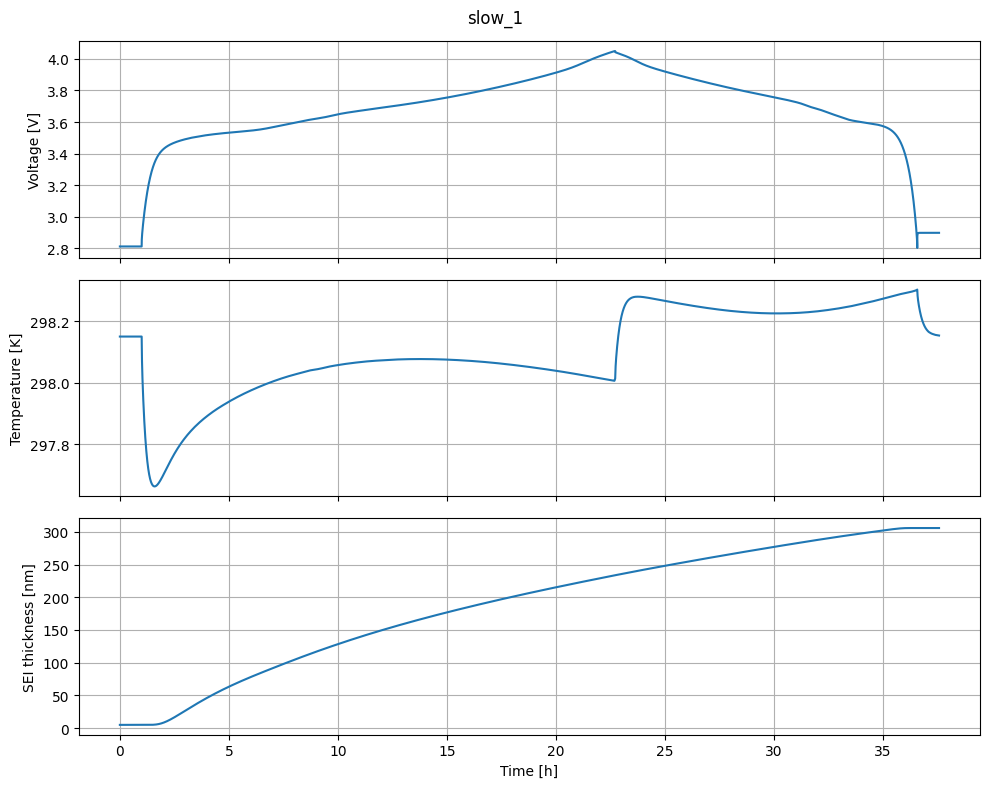

,Time [s],Current [A],Terminal voltage [V],Cell temperature [K],Negative SEI thickness [nm],SEI growth rate [nm/s],Total lithium capacity [A.h],Cumulative charge [A.s],Sqrt cumulative charge [sqrt(A.s)],Regime,Protocol ID
0,0.0,0.0,2.810094,298.15,5.0,0.000000e+00,5.411385,0.0,0.0,slow,1
1,1.0,0.0,2.810094,298.15,5.0,3.582837e-08,5.411385,0.0,0.0,slow,1
2,2.0,0.0,2.810094,298.15,5.0,3.582837e-08,5.411385,0.0,0.0,slow,1
3,3.0,0.0,2.810094,298.15,5.0,3.582837e-08,5.411385,0.0,0.0,slow,1
4,4.0,0.0,2.810094,298.15,5.0,3.582837e-08,5.411385,0.0,0.0,slow,1


In [ ]:
# Testing one protocol before running everything.


test_df, test_sol = solve_and_export("slow_1", experiments["slow_1"], plot=True)
test_df.head()


## 7. Generate all datasets

If `slow_1.csv` is alreasy generated in the test cell, this loop will overwrite it.


In [ ]:
GENERATE_ALL = True  # Change to True to generate all 18 datasets.

if GENERATE_ALL:
    generated = []
    failed = []

    for name, experiment in experiments.items():
        try:
            df, sol = solve_and_export(name, experiment, plot=False)
            generated.append(name)
        except Exception as e:
            print(f"FAILED: {name}")
            print(e)
            failed.append((name, str(e)))

    print("\nGeneration complete.")
    print("Generated:", generated)
    print("Failed:", failed)
else:
    print("GENERATE_ALL is False. Change it to True to generate all datasets.")



Running multi_1 ...
Saved ../data/raw/multi_1.csv | shape=(155258, 11) | duration=43.13 h

Running multi_2 ...
Saved ../data/raw/multi_2.csv | shape=(181653, 11) | duration=50.46 h

Running multi_3 ...
Saved ../data/raw/multi_3.csv | shape=(185483, 11) | duration=51.52 h

Running multi_4 ...
Saved ../data/raw/multi_4.csv | shape=(134269, 11) | duration=37.30 h

Running multi_5 ...
Saved ../data/raw/multi_5.csv | shape=(188256, 11) | duration=52.29 h

Running multi_6 ...
Saved ../data/raw/multi_6.csv | shape=(117404, 11) | duration=32.61 h

Running slow_1 ...
Saved ../data/raw/slow_1.csv | shape=(135288, 11) | duration=37.58 h

Running slow_2 ...
Saved ../data/raw/slow_2.csv | shape=(110280, 11) | duration=30.63 h

Running slow_3 ...
Saved ../data/raw/slow_3.csv | shape=(88826, 11) | duration=24.67 h

Running slow_4 ...
Saved ../data/raw/slow_4.csv | shape=(127575, 11) | duration=35.44 h

Running slow_5 ...
Saved ../data/raw/slow_5.csv | shape=(87456, 11) | duration=24.29 h

Running sl

## 8. Check generated files

In [11]:
csv_files = sorted(RAW_DIR.glob("*.csv"))
print("CSV files found:", len(csv_files))
for path in csv_files:
    print(path.name)

# Quick shape check
summary = []
for path in csv_files:
    df = pd.read_csv(path)
    summary.append({
        "file": path.name,
        "rows": len(df),
        "columns": len(df.columns),
        "duration_h": df["Time [s]"].max() / 3600 if "Time [s]" in df.columns else np.nan,
    })

summary_df = pd.DataFrame(summary)
summary_df


CSV files found: 18
fast_1.csv
fast_2.csv
fast_3.csv
fast_4.csv
fast_5.csv
fast_6.csv
multi_1.csv
multi_2.csv
multi_3.csv
multi_4.csv
multi_5.csv
multi_6.csv
slow_1.csv
slow_2.csv
slow_3.csv
slow_4.csv
slow_5.csv
slow_6.csv


,file,rows,columns,duration_h
0,fast_1.csv,15473,11,4.297778
1,fast_2.csv,12903,11,3.583889
2,fast_3.csv,11017,11,3.060000
3,fast_4.csv,12926,11,3.590278
4,fast_5.csv,9542,11,2.650278
5,fast_6.csv,12173,11,3.381111
6,multi_1.csv,155258,11,43.126944
7,multi_2.csv,181653,11,50.458889
8,multi_3.csv,185483,11,51.522778
9,multi_4.csv,134269,11,37.296667
